# Multi-Objective Diet Optimization and Selection Framework — Replication Notebook

## Introduction

This notebook implements the three-stage multi-objective optimization and decision-support framework described in the accompanying paper (*Multi-Objective Diet Optimization and Selection Framework for Healthy and Sustainable Diet Design*, submitted to Food Policy). It generates all numerical results, tables, and figures reported for one Cambodian region.

The three stages correspond to Sections 2.1–2.3 of the paper:
1. **Multi-objective linear programming model** — jointly minimizes diet cost, diet-related greenhouse gas emissions (GHGe), and deviation from observed consumption patterns, subject to nutritional adequacy and dietary balance constraints (Section 2.1).
2. **Revised Normal Boundary Intersection (RNBI)** — generates a finite, well-distributed set of Pareto-efficient diet baskets (Section 2.2).
3. **VIKOR multi-criteria decision analysis** — ranks Pareto-efficient solutions under alternative weighting schemes to identify compromise solutions (Section 2.3).

## Configuration

This notebook is configured for a single region. To replicate results for a different region, modify the `region` and `specific_results_dir` variables in Section 2.2 (Parameters). The four available regions are:
- `'Kampot and Kep'` → `results/a-kampot-and-kep-woman/`
- `'Mondulkiri and Rattanakiri'` → `results/b-mondulkiri-and-rattanakiri/`
- `'Preah Vihear and Stung Treng'` → `results/c-preah-vihear-and-stung-treng/`
- `'Prey Veng'` → `results/d-prey-veng/`

## Paper output mapping

| Paper output | Notebook section | Description |
|---|---|---|
| Figure 1 | Section 4.2, 5.3 | Pareto-optimal solution space with compromise solutions |
| Table 2 | Section 4.5 | Lexicographic reference solutions |
| Table 3 | Section 5.2 | VIKOR compromise solutions under alternative weighting schemes |
| Table 4 | Section 6.1 | Sub-food-group composition of compromise solutions |
| Figure 2 | Section 6.1 | Diet composition bar plots (weight and energy contribution) |
| Figure 3 | Section 6.4 | Compromise solutions vs. current consumption patterns |

## 2. Setup

### 2.1 Imports and directory configuration

Load standard libraries and the project-specific classes that implement data handling, model construction, optimization, and visualization.

In [1]:
import os
import sys
import pickle
import pandas as pd
import numpy as np
from copy import copy

# Set up directories
project_dir = os.path.dirname(os.path.dirname(os.getcwd()))
code_dir = os.path.join(project_dir, 'code')
classes_dir = os.path.join(code_dir, 'classes')
data_dir = os.path.join(project_dir, 'data')
results_dir = os.path.join(project_dir, 'results')
specific_results_dir = os.path.join(results_dir, 'b-mondulkiri-and-rattanakiri')

# Add classes directory to sys.path
sys.path.append(classes_dir)

# Import custom classes
from DATA import Data
from MODEL import Model
from SOLUTION import Solution
from MOLP import Molp
from RNBI import RNBI
from FOODBASKET import FoodBasket
from MULTIPLEFOODBASKETS import MultipleFoodBaskets
from VIKOR import VIKOR
from PLOTS import *

### 2.2 Parameters

Define the population group, region, optimization settings, and VIKOR weighting schemes. These parameters control the entire pipeline. To replicate results for a different region, change `region` and `specific_results_dir` above.

In [2]:
# Population group for nutrient reference values
population_group = 'Woman of reproductive age'

# Region for food prices, consumption patterns, and environmental data
# Options: 'Kampot and Kep', 'Prey Veng', 'Mondulkiri and Rattanakiri', 'Preah Vihear and Stung Treng'
region = 'Mondulkiri and Rattanakiri'

# Objective upper bounds for the multi-objective LP (None = uncapped)
objective_upper_bounds = {
    'Cost (KHR/day)': None,
    'Dietary-shift index (unitless)': 2,
    'CO2e (Kg/day)': 5}

# VIKOR weighting schemes: each assigns relative importance to the three objectives
set_of_weights = {
    'Shift-weighted (66%)':{'Cost (KHR/day)': 0.16, 'Dietary-shift index (unitless)': 0.66, 'CO2e (Kg/day)': 0.16},
    'Cost-weighted (66%)':{'Cost (KHR/day)': 0.66, 'Dietary-shift index (unitless)': 0.16, 'CO2e (Kg/day)': 0.16},
    'Emissions-weighted (66%)':{'Cost (KHR/day)': 0.16, 'Dietary-shift index (unitless)': 0.16, 'CO2e (Kg/day)': 0.66},
    'Equal weights':{'Cost (KHR/day)': 0.33, 'Dietary-shift index (unitless)': 0.33, 'CO2e (Kg/day)': 0.33}
}

# Number of cutting points for the RNBI method (controls Pareto front resolution)
num_cut_points = 15

# VIKOR compromise parameter: v=0.5 balances group utility and individual regret
v_vikor = 0.5

# RNBI reference plane method
method = 'nadir'

# Labels for lexicographic (extreme) solutions
LEXI_LABELS = {'e1': 'L_C', 'e2': 'L_DS', 'e3': 'L_E'}

# Color scheme for VIKOR compromise solutions (used in plots)
colors_baskets = {
    'Shift-weighted (66%)': '#6600cc',
    'Cost-weighted (66%)': '#ffce00',
    'Emissions-weighted (66%)': '#008055',
    'Equal weights': '#ff5500',
}

### 2.3 Output file names

Construct file names for all outputs (serialized objects, plots, and Excel files). Names encode the population group and region for traceability.

In [3]:
# Serialized objects
nbi_object_file = 'nbi-'+population_group.replace(' ', '_')+'_'+region.replace(' ', '_')+'.pkl'
mfb_object_file = 'mfb-'+population_group.replace(' ', '_')+'_'+region.replace(' ', '_')+'.pkl'

# Plot files
double_pareto_plot_file = 'double_pareto_plot_'+population_group.replace(' ', '_')+'_'+region.replace(' ', '_')+'.png'
single_pareto_plot_file = 'single_pareto_plot_'+population_group.replace(' ', '_')+'_'+region.replace(' ', '_')+'.png'
food_subgroup_composition_plot_file = 'food_subgroup_composition_plot_'+population_group.replace(' ', '_')+'_'+region.replace(' ', '_')+'.png'
food_subgroup_energy_plot_file = 'food_subgroup_energy_plot_'+population_group.replace(' ', '_')+'_'+region.replace(' ', '_')+'.png'
selected_baskets_vs_current_metrics_plot_file = 'selected_baskets_vs_current_metrics_plot_'+population_group.replace(' ', '_')+'_'+region.replace(' ', '_')+'.png'

# Excel files
all_baskets_excel_file = 'all_baskets_'+population_group.replace(' ', '_')+'_'+region.replace(' ', '_')+'.xlsx'
extreme_baskets_excel_file = 'extreme_baskets_'+population_group.replace(' ', '_')+'_'+region.replace(' ', '_')+'.xlsx'
selected_baskets_excel_file = 'selected_baskets_'+population_group.replace(' ', '_')+'_'+region.replace(' ', '_')+'.xlsx'
current_consumption_metrics_excel_file = 'current_consumption_metrics_'+population_group.replace(' ', '_')+'_'+region.replace(' ', '_')+'.xlsx'

## 3. Data Loading and Model Construction

The `Data` class loads all input datasets (food prices, nutrient composition, GHGe coefficients, consumption patterns) from the `data/` directory. The `Model` class constructs the multi-objective linear programming formulation with nutritional adequacy, dietary balance, and feasibility constraints. The `Molp` class computes the ideal and nadir points used for RNBI normalization.

In [4]:
# Create Data object specifying the data directory
data = Data(data_dir)
# Create Model object using the Data object, population group, and region
model = Model(data, population_group, region)
# Set upper bounds for objective functions
model.set_objective_limits(objective_upper_bounds)
# Create Molp object using the Model object
molp = Molp(model)

## 4. Stage 1 — Pareto-Efficient Solution Generation (RNBI)

The Revised Normal Boundary Intersection method generates a representative and well-distributed set of Pareto-efficient diet baskets by systematically sampling the non-dominated frontier across the three objectives (cost, dietary shift, GHGe). This corresponds to Section 2.2 of the paper.

### 4.1 Run RNBI

Generate the Pareto-efficient solution set. The method places equidistant reference points on a normalized boundary plane and solves a linear program for each to identify non-dominated solutions. The resulting set is saved as a serialized object for reproducibility.

In [5]:
# Create and run RNBI method
nbi = RNBI(model, cutting_points=num_cut_points, normalize=True, plane_point=method)

# Print summary of the RNBI method
print(nbi.num_solutions_report())
print('Total execution time: ', nbi.total_execution_time)

# Save RNBI object as pickle object
with open(os.path.join(specific_results_dir, nbi_object_file), 'wb') as f:
    pickle.dump(nbi, f)

{'Reference Points': 120, 'Efficient': 30, 'Dominated': 10, 'Infeasible': 83, '% Efficient': 25.0, '% Dominated': 8.333, '% Infeasible': 69.167}
Total execution time:  6.06


### 4.2 Visualize Pareto-optimal solution space

Display 2D projections of the three-dimensional Pareto front. Each point represents a feasible diet basket; color encodes the value of the omitted objective. These projections correspond to elements of Figure 1 in the paper.

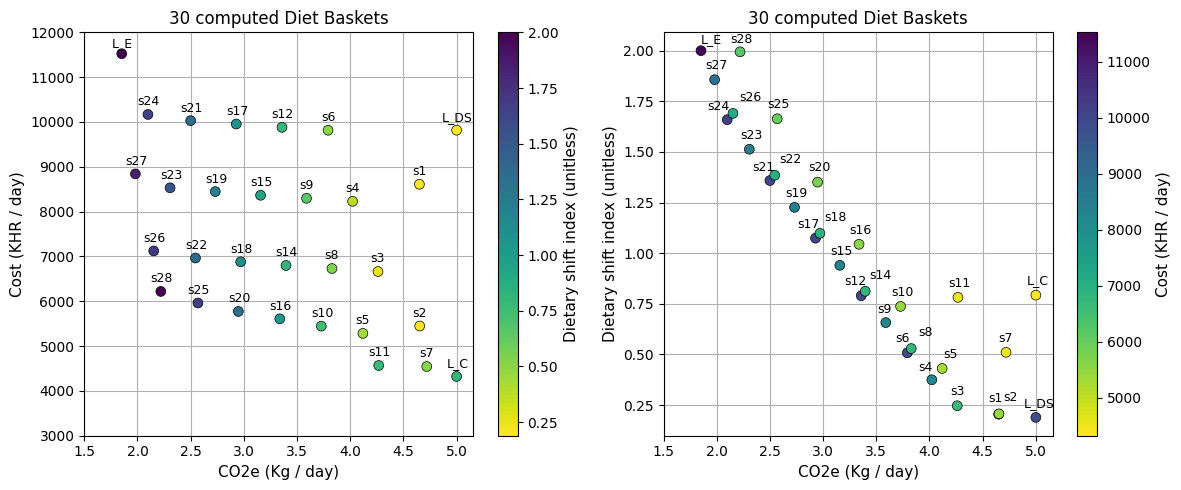

In [6]:
plot_file_path = os.path.join(specific_results_dir, double_pareto_plot_file)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
plt.sca(ax1)
plot_NBI_3D_to_2D_with_color_scale(nbi, objectives_to_use=[1,0,1], normalize_scale=True, swap_axes=True, best_alternative=None, export=True, tags=True)
plt.sca(ax2)
plot_NBI_3D_to_2D_with_color_scale(nbi, objectives_to_use=[0,1,1], normalize_scale=True, swap_axes=True, best_alternative=None, export=True, tags=True)
fig.tight_layout()
fig.savefig(plot_file_path, format='png', bbox_inches='tight', dpi=330)
plt.show()
plt.close(fig)

### 4.3 Extract and inspect all solutions

Create the `MultipleFoodBaskets` container to access objective values and diet compositions across all Pareto-efficient solutions. This produces dataframes for objectives, sub-food-group composition (g/day), food-item composition, and energy contribution by food group.

In [7]:
mfb = MultipleFoodBaskets(nbi)

# Objective value dataframe and formatting
objectives_df = mfb.multiple_baskets_method_df('objectives_df', fillna=0).round(2).replace(0, '')

# Food subgroups composition dataframe and formatting
basket_composition = mfb.multiple_baskets_method_df('basket_food_subgroups_df', fillna=0).round(1).replace(0, '')
food_subgroups_id = mfb.data.food_subgroup_id_dict # {food_subgroup_name : id_int}
sorted_food_subroups = [food_subgroup for food_subgroup in list(food_subgroups_id.keys()) if food_subgroup in basket_composition.index] # Only keep the food subgroups that are in the basket composition basket_composition.index
food_subgroups_basket_composition = basket_composition.loc[sorted_food_subroups,:]

# Food items composition dataframe and formatting
mfb.multiple_baskets_method_df('basket_composition_df', fillna=0).round(1).replace(0,'')
food_items_id = mfb.data.food_items_id_dict # {food_item_name : id_int}
sorted_food_items = [food_item for food_item in list(food_items_id.keys()) if food_item in mfb.multiple_baskets_method_df('basket_composition_df', fillna=0).index] # Only keep the food items that are in the basket composition basket_composition.index
food_items_basket_composition = mfb.multiple_baskets_method_df('basket_composition_df', fillna=0).loc[sorted_food_items,:].round(1).replace(0,'')
food_items_basket_composition = food_items_basket_composition.loc[(food_items_basket_composition != '').any(axis=1)] # delete rows with all '' values

# Food subgroups energy percentage dataframe and formatting
food_subgroup_energy_percentage_df = mfb.multiple_baskets_method_df('basket_energy_contribution_percentage_food_subgroups_df', fillna=0).round(1)

# Save mfb pickle object
mfb_object_path = os.path.join(specific_results_dir, mfb_object_file)
with open(mfb_object_path, 'wb') as f:
    pickle.dump(mfb, f)

Inspect the objective values across all generated solutions. Columns labeled `e1`, `e2`, `e3` correspond to lexicographic solutions (minimum cost, minimum dietary shift, minimum GHGe respectively); remaining columns are interior Pareto-efficient solutions.

In [8]:
# Objective values of all solutions
objectives_df

,e2,s1,s2,s3,s4,s5,s6,s7,s8,s9,...,s20,s21,s22,s23,s24,s25,s26,s27,s28,e3
Cost (KHR/day),9816.99,8609.98,5448.30,6663.44,8229.78,5283.01,9815.29,4543.71,6730.32,8296.43,...,5773.00,10029.73,6964.79,8530.96,10167.53,5961.19,7122.84,8840.85,6219.23,11522.94
Dietary-shift index (unitless),0.19,0.20,0.21,0.25,0.38,0.43,0.51,0.51,0.53,0.66,...,1.35,1.36,1.38,1.51,1.66,1.66,1.69,1.86,1.99,2.00
CO2e (Kg/day),5.00,4.65,4.65,4.26,4.02,4.12,3.79,4.72,3.83,3.59,...,2.95,2.50,2.54,2.31,2.10,2.57,2.15,1.98,2.22,1.85


In [9]:
# Food subgroup composition of all solutions (g/day)
food_subgroups_basket_composition.head()

,e2,s1,s2,s3,s4,s5,s6,s7,s8,s9,...,s20,s21,s22,s23,s24,s25,s26,s27,s28,e3
Rice,351.8,313.5,309.2,260.6,235.8,232.7,210.0,304.5,206.0,181.2,...,123.6,45.4,40.4,15.6,,81.4,,,24.3,
Other and mixed cereals,5.3,8.2,14.4,35.2,58.0,60.2,81.7,2.2,85.4,108.2,...,160.4,233.0,237.6,260.5,274.8,199.3,274.8,274.8,258.7,274.8
"Roots, tubers and plantains (general)",,,12.4,23.0,23.0,23.0,23.0,,23.0,23.0,...,23.0,23.0,23.0,23.0,23.0,23.0,23.0,23.0,,23.0
Leafy vegetables,124.3,124.3,124.3,124.3,124.3,91.0,124.3,111.5,124.3,124.3,...,94.3,124.3,85.3,124.3,124.3,110.9,113.0,124.3,114.3,124.3
Other vegetables,75.7,75.7,75.7,164.8,75.7,109.0,75.7,88.5,180.9,75.7,...,105.7,75.7,114.7,75.7,75.7,89.1,87.0,75.7,85.7,75.7


### 4.4 Compute baseline reference values

Compute the cost, GHGe, and dietary-shift values for the current (baseline) diet and the ideal point. The current diet is defined by median observed consumption from CSES 2021, evaluated using model prices and GHGe coefficients. The Adult Female Equivalent (AFE) factor adjusts per-capita survey values to the reference individual.

In [10]:
# Adult Female Equivalent adjustment factor for the reference population group
afe_factor = data.afe_factor(population_group)
current_co2 = data.current_environmental_impact_afe_total_dict(region)['CO2_food_afe_med']*afe_factor
current_cost = float(data.current_food_expenditure_afe_by_percentile_df(region).loc[50])*afe_factor
current_dev = 0
iqr = [float(data.current_food_expenditure_afe_by_percentile_df(region).loc[25])*afe_factor, float(data.current_food_expenditure_afe_by_percentile_df(region).loc[75])*afe_factor]
current_basket = [current_cost, current_dev, current_co2]
ideal_basket = list(nbi.original_molp.ideal_point())

additional_sols = {
    'Current': current_basket,
    'Ideal': ideal_basket}

# Save all food baskets (objectives, sub-food-group and food-item compositions, energy shares)
output_file_path = os.path.join(specific_results_dir, all_baskets_excel_file)
with pd.ExcelWriter(output_file_path, engine='xlsxwriter') as writer:
    objectives_df.to_excel(writer, sheet_name='objectives', index=True)
    food_subgroups_basket_composition.to_excel(writer, sheet_name='food_subgroups_comp', index=True)
    food_items_basket_composition.to_excel(writer, sheet_name='food_items_comp', index=True)
    food_subgroup_energy_percentage_df.to_excel(writer, sheet_name='food_subgroups_energy', index=True)

### 4.5 Lexicographic solutions (Table 2)

Extract the lexicographic (extreme) solutions — diet baskets that strictly minimize one objective at a time. These serve as interpretive anchors for understanding the trade-off space, not as candidate diets. Combined with the current diet and ideal point, they define the reference frame reported in Table 2 of the paper.

In [11]:
extreme_objectives_df = objectives_df.filter(like='e', axis=1)
extreme_food_subgroups_basket_composition = food_subgroups_basket_composition.filter(like='e', axis=1)
extreme_food_items_basket_composition = food_items_basket_composition.filter(like='e', axis=1)

objective_names = objectives_df.index.tolist()
current_basket_df = pd.DataFrame(current_basket, index=objective_names, columns=['Current'])
ideal_basket_df = pd.DataFrame(ideal_basket, index=objective_names, columns=['Ideal'])
# Add current and ideal baskets to the extreme objectives dataframe
extreme_objectives_df = pd.concat([extreme_objectives_df, current_basket_df, ideal_basket_df], axis=1)

# Save extreme food baskets
output_file_path = os.path.join(specific_results_dir, extreme_baskets_excel_file)
with pd.ExcelWriter(output_file_path, engine='xlsxwriter') as writer:
    extreme_objectives_df.to_excel(writer, sheet_name='objectives_extreme', index=True)
    extreme_food_subgroups_basket_composition.to_excel(writer, sheet_name='food_subgroups_comp_extreme', index=True)
    extreme_food_items_basket_composition.to_excel(writer, sheet_name='food_items_comp_extreme', index=True)

In [12]:
# Lexicographic solutions with current diet and ideal point (Table 2)
extreme_objectives_df

,e2,e1,e3,Current,Ideal
Cost (KHR/day),9816.99,4322.58,11522.94,5462.845703,4322.585250
Dietary-shift index (unitless),0.19,0.79,2.00,0.000000,0.188987
CO2e (Kg/day),5.00,5.00,1.85,4.700830,1.852061


## 5. Stage 2 — Compromise Selection (VIKOR)

The VIKOR method ranks the Pareto-efficient solutions under alternative, explicitly stated objective-weighting schemes to identify compromise solutions. This separates trade-off generation (RNBI) from preference articulation (VIKOR), as described in Section 2.3 of the paper. The weighting schemes are illustrative and are not derived from stakeholder elicitation.

### 5.1 Run VIKOR under alternative weighting schemes

For each weighting scheme, VIKOR computes group utility (S), individual regret (R), and the composite index (Q). The alternative with the lowest Q value is selected as the compromise solution.

In [13]:
objectives_df

,e2,s1,s2,s3,s4,s5,s6,s7,s8,s9,...,s20,s21,s22,s23,s24,s25,s26,s27,s28,e3
Cost (KHR/day),9816.99,8609.98,5448.30,6663.44,8229.78,5283.01,9815.29,4543.71,6730.32,8296.43,...,5773.00,10029.73,6964.79,8530.96,10167.53,5961.19,7122.84,8840.85,6219.23,11522.94
Dietary-shift index (unitless),0.19,0.20,0.21,0.25,0.38,0.43,0.51,0.51,0.53,0.66,...,1.35,1.36,1.38,1.51,1.66,1.66,1.69,1.86,1.99,2.00
CO2e (Kg/day),5.00,4.65,4.65,4.26,4.02,4.12,3.79,4.72,3.83,3.59,...,2.95,2.50,2.54,2.31,2.10,2.57,2.15,1.98,2.22,1.85


In [14]:
best_baskets = {}
for weight_name, weights in set_of_weights.items():
    vikor = VIKOR(objectives_df, weights, v_vikor)
    vikor.compute_S_R_Q(weights)
    best_basket = vikor.best_alternative('Q')
    best_baskets[weight_name] = best_basket

best_baskets_list = list(best_baskets.values())

# Mapping from weighting scheme to selected Pareto solution identifier
best_baskets_df = pd.DataFrame(best_baskets.values(), index=best_baskets.keys(), columns=['Selected Baskets'])
best_baskets_df

,Selected Baskets
Shift-weighted (66%),s3
Cost-weighted (66%),s11
Emissions-weighted (66%),s26
Equal weights,s16


### 5.2 Extract selected compromise solutions (Table 3)

Filter objectives and compositions for the VIKOR-selected solutions. These results correspond to Table 3 in the paper, reporting dietary-shift index, cost, and GHGe for each weighting scheme.

In [15]:
# Filter objective values for selected best baskets
selected_objectives_df = objectives_df.loc[:, best_baskets_list]
# Filter food subgroup composition for selected best baskets
selected_food_subgroups_basket_composition = food_subgroups_basket_composition.loc[:, best_baskets_list]
# Filter food items composition for selected best baskets
selected_food_items_basket_composition = copy(food_items_basket_composition.loc[:, best_baskets_list])
# delete rows with all '' values
selected_food_items_basket_composition = selected_food_items_basket_composition.loc[(selected_food_items_basket_composition != '').any(axis=1)]

# Save to excel
output_file_path = os.path.join(specific_results_dir, selected_baskets_excel_file)
with pd.ExcelWriter(output_file_path, engine='xlsxwriter') as writer:
    best_baskets_df.to_excel(writer, sheet_name='best_baskets', index=True)
    selected_objectives_df.to_excel(writer, sheet_name='objectives_selected', index=True)
    selected_food_subgroups_basket_composition.to_excel(writer, sheet_name='food_subgroups_comp_selected', index=True)
    selected_food_items_basket_composition.to_excel(writer, sheet_name='food_items_comp_selected', index=True)

In [16]:
# Compromise solution objectives (Table 3)
selected_objectives_df

,s3,s11,s26,s16
Cost (KHR/day),6663.44,4566.56,7122.84,5608.32
Dietary-shift index (unitless),0.25,0.78,1.69,1.04
CO2e (Kg/day),4.26,4.27,2.15,3.34


In [17]:
# Sub-food-group composition of compromise solutions (Table 4)
selected_food_subgroups_basket_composition

,s3,s11,s26,s16
Rice,260.6,282.1,,168.8
Other and mixed cereals,35.2,21.7,274.8,118.9
"Roots, tubers and plantains (general)",23.0,,23.0,23.0
Leafy vegetables,124.3,117.9,113.0,76.0
Other vegetables,164.8,82.1,87.0,124.0
Fruits (other),172.8,200.0,172.8,172.8
Yellow and orange fruits,27.2,,27.2,27.2
Eggs,40.4,134.0,52.5,112.1
Freshwater fish,69.6,,45.8,22.4
Poultry,44.1,10.0,42.0,20.0


In [18]:
# Food-item level composition of compromise solutions
selected_food_items_basket_composition.head()

,s3,s11,s26,s16
"Rice, white, polished, raw",260.6,282.1,,168.8
"Noodles, egg, dry, enriched",35.2,21.7,274.8,118.9
"Plantain, all varieties",,,,23.0
"Sweet potato, purple skin, pale yellow flesh, raw",23.0,,23.0,
"Leaf, amaranth, spiney, raw",,117.9,,76.0


### 5.3 Visualize compromise solutions in objective space (Figure 1)

Plot the Pareto-optimal solution space with the VIKOR-selected compromise solutions highlighted alongside the current diet, ideal point, and lexicographic reference solutions. This visualization corresponds to Figure 1 in the paper.

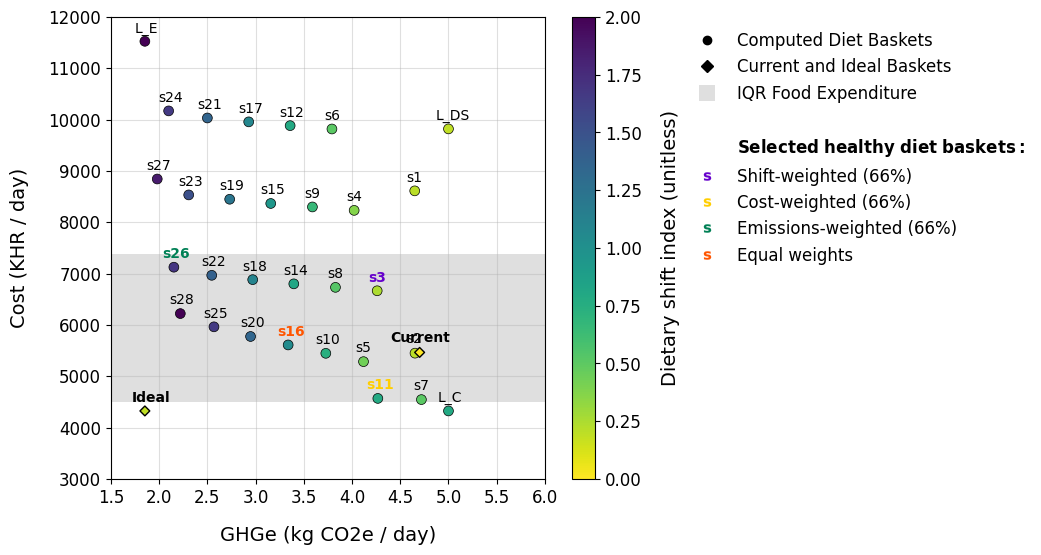

In [19]:
plot_file_path = os.path.join(specific_results_dir, single_pareto_plot_file)

# Create figure and axes, then pass them to the function
fig, ax = plt.subplots(figsize=(7, 6))  # Increased width to accommodate legend
fig, ax = plot_NBI_3D_to_2D_complete(
    nbi,
    objectives_to_use=[1,0,1],
    best_baskets=best_baskets,
    colors_baskets=colors_baskets,
    normalize_scale=True,
    swap_axes=True,
    export=True,
    tags=True,
    additional_solutions=additional_sols,
    interquartile_range=iqr,
    fig=fig,
    ax=ax
)
# Don't call tight_layout() as it can interfere with the legend positioning
fig.savefig(plot_file_path, format='png', bbox_inches='tight', dpi=500)
plt.show()
plt.close(fig)

## 6. Stage 3 — Diet Composition Analysis

This section examines the sub-food-group composition of the compromise solutions and compares them with current consumption patterns. The compositional analysis corresponds to Table 4 and Figures 2–3 in the paper.

### 6.1 Sub-food-group composition plots (Figure 2)

Stacked bar plots showing the percentage contribution of each sub-food group to total diet weight and total dietary energy across all generated solutions. These visualizations correspond to Figure 2 in the paper.

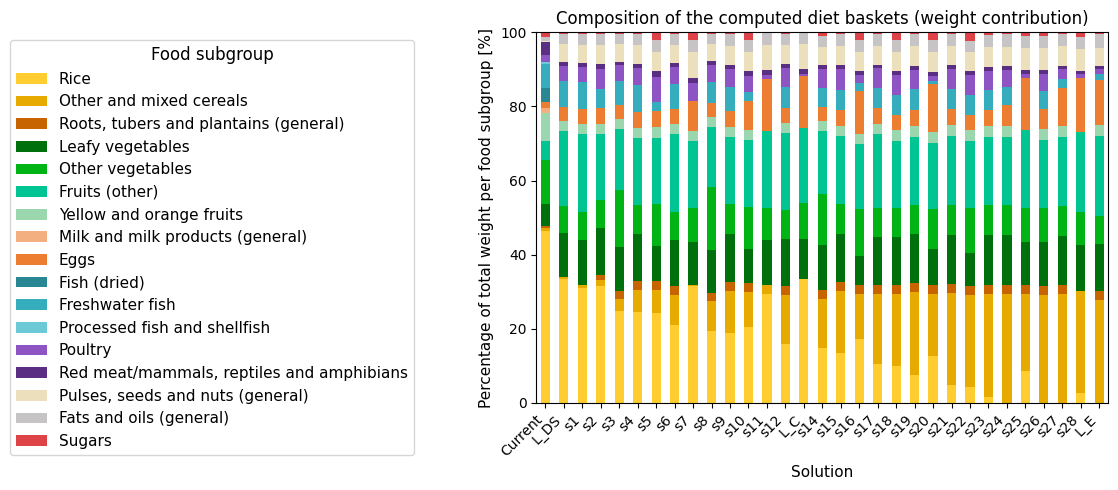

In [20]:
# --- Weight contribution plot ---
plot_file_path = os.path.join(specific_results_dir, food_subgroup_composition_plot_file)

food_subgroup_df = mfb.multiple_baskets_method_df('basket_food_subgroups_df', fillna=0)

# Read food subgroup color mapping
colors_df = pd.read_excel(os.path.join(data_dir, 'food_subgroup_colors.xlsx'),  index_col=0)
color_dict = colors_df['color_code'].to_dict()
# Current basket (by food subgroup)
current = data.current_food_subgroup_consumption_df_filtered(population_group, region)
# Merge food_subgroup_df and current conserving all rows (fill with 0s)
merged_df = pd.merge(current, food_subgroup_df, how='outer', left_index=True, right_index=True)
merged_df = merged_df.fillna(0)

title_label_dict = {'title': 'Composition of the computed diet baskets (weight contribution)',
                    'xlabel': 'Solution',
                    'ylabel': 'Percentage of total weight per food subgroup [%]',
                    'legend_title': 'Food subgroup'}

df_percentages = merged_df.div(merged_df.sum(axis=0), axis=1) * 100
df_percentages = df_percentages.rename(columns=LEXI_LABELS)

# Create figure and pass axes to the function
fig, ax = plt.subplots(figsize=(12, 5))
plot_food_baskets_subgroups(df_percentages, colors_df, title_label_dict=title_label_dict, export=True, ax=ax)
fig.tight_layout()
fig.savefig(plot_file_path, format='png', bbox_inches='tight', dpi=330)
plt.show()
plt.close(fig)

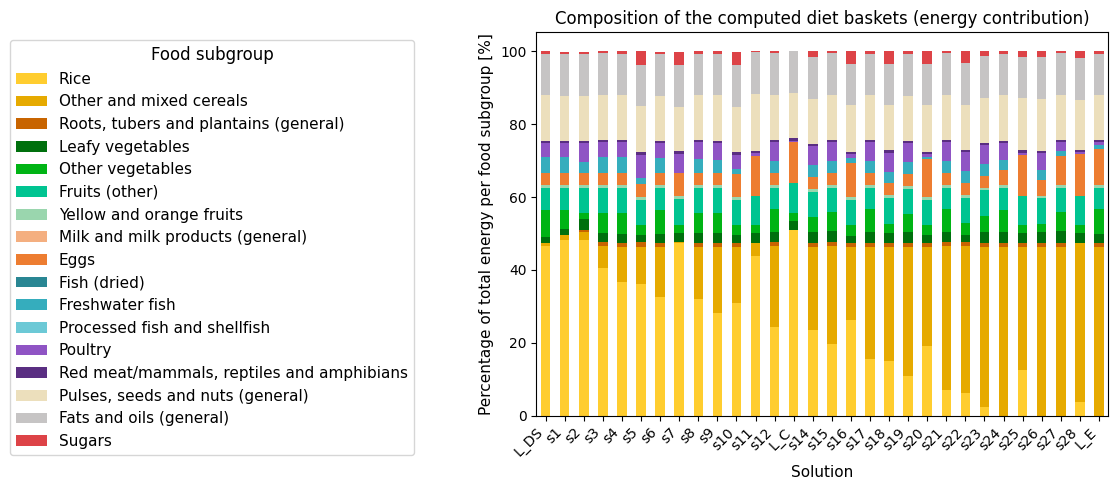

In [21]:
# --- Energy contribution plot ---
plot_file_path = os.path.join(specific_results_dir, food_subgroup_energy_plot_file)

title_label_dict = {'title': 'Composition of the computed diet baskets (energy contribution)',
                    'xlabel': 'Solution',
                    'ylabel': 'Percentage of total energy per food subgroup [%]',
                    'legend_title': 'Food subgroup'}

# Create figure and pass axes to the function
fig, ax = plt.subplots(figsize=(12, 5))

food_subgroup_energy_percentage_df = food_subgroup_energy_percentage_df.rename(columns=LEXI_LABELS)

plot_food_baskets_subgroups(food_subgroup_energy_percentage_df, colors_df, title_label_dict=title_label_dict, export=True, ax=ax)
fig.tight_layout()
fig.savefig(plot_file_path, format='png', bbox_inches='tight', dpi=330)
plt.show()
plt.close(fig)

### 6.2 Current consumption patterns

Compute distributional statistics (median, mean, 5th–95th percentile range) of observed sub-food-group consumption from CSES 2021, used as the baseline for comparison with optimized diet baskets.

In [22]:
current_consumption_metrics = data.current_food_subgroup_metrics_df_filtered(population_group, region).round(2)

food_subgroups_id = data.food_subgroup_id_dict # {food_subgroup_name : id_int}
sorted_food_subroups = [food_subgroup for food_subgroup in list(food_subgroups_id.keys()) if food_subgroup in current_consumption_metrics.index]
current_consumption_metrics = current_consumption_metrics.loc[sorted_food_subroups,:]

# Save current consumption metrics to Excel
output_file_path = os.path.join(specific_results_dir, current_consumption_metrics_excel_file)
with pd.ExcelWriter(output_file_path, engine='xlsxwriter') as writer:
    current_consumption_metrics.to_excel(writer, sheet_name='current_consumption', index=True)

In [23]:
current_consumption_metrics.head()

,5th percentile (grams/day),95th percentile (grams/day),mean (grams/day),median (grams/day),Std (grams/day)
Rice,220.06,672.47,423.37,409.53,143.19
Other and mixed cereals,0.00,31.35,7.60,0.00,11.36
"Roots, tubers and plantains (general)",0.00,23.01,4.91,0.00,14.83
Leafy vegetables,7.60,124.34,55.02,49.57,38.41
Other vegetables,45.65,216.69,108.40,95.05,65.70


### 6.3 Compromise solutions vs. current consumption (Figure 3)

Compare the sub-food-group composition of the VIKOR compromise solutions against the distributional range of current consumption. Points represent optimized basket quantities; box-and-whisker elements show the observed consumption distribution. This visualization corresponds to Figure 3 in the paper.

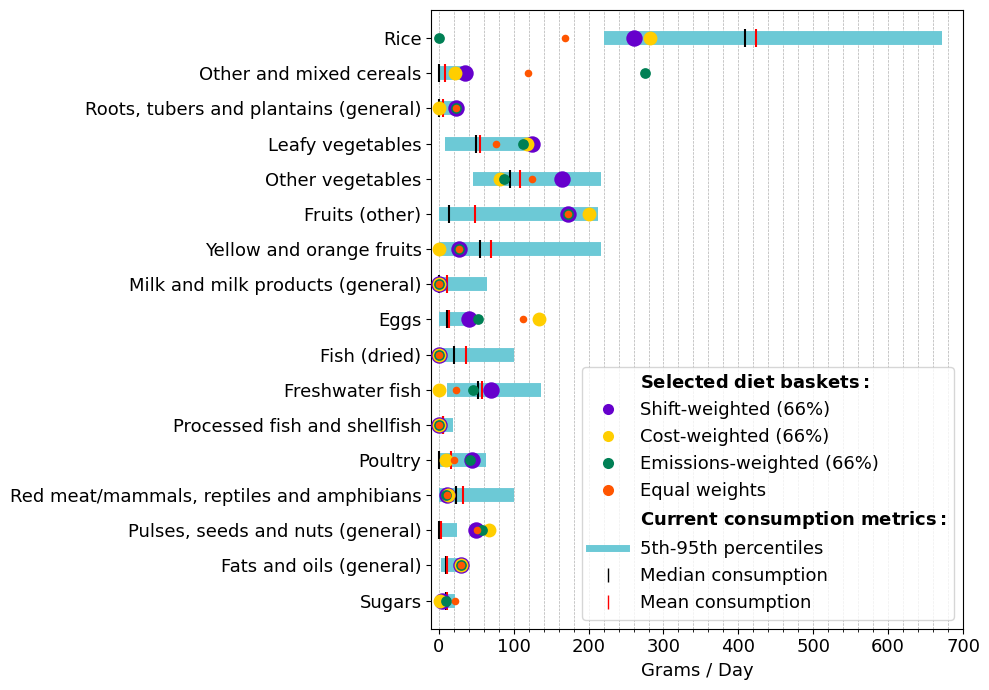

In [24]:
# Rename columns from solution identifiers to weighting scheme names
renamed_food_subgroups_basket_composition = selected_food_subgroups_basket_composition.rename(columns={v: k for k, v in best_baskets.items()})
renamed_food_subgroups_basket_composition.head()

plot_file_path = os.path.join(specific_results_dir, selected_baskets_vs_current_metrics_plot_file)

size_baskets = {
    'Shift-weighted (66%)': 140,
    'Cost-weighted (66%)': 100,
    'Emissions-weighted (66%)': 60,
    'Equal weights': 30}

# Create figure and pass axes to the function
fig, ax = plt.subplots(figsize=(10, 7))  # Use same size as in function
plot_food_group_distribution_selected_baskets(
    current_consumption_metrics, 
    renamed_food_subgroups_basket_composition, 
    colors_df, 
    colors_baskets,
    size_baskets,
    title=False,
    export=True, 
    ax=ax
)
fig.tight_layout()
fig.savefig(plot_file_path, format='png', bbox_inches='tight', dpi=330)
plt.show()
plt.close(fig)

## 7. Results Summary

All outputs have been saved to `specific_results_dir`. The following files were generated:

**Serialized objects** (for programmatic reuse):
- `nbi-*.pkl` — RNBI solution set
- `mfb-*.pkl` — MultipleFoodBaskets container

**Excel files** (numerical results):
- `all_baskets_*.xlsx` — Objective values, sub-food-group composition, food-item composition, and energy shares for all Pareto-efficient solutions
- `extreme_baskets_*.xlsx` — Lexicographic solutions with current diet and ideal point (Table 2)
- `selected_baskets_*.xlsx` — VIKOR compromise solutions and their compositions (Tables 3–4)
- `current_consumption_metrics_*.xlsx` — Observed consumption distributional statistics

**Plots** (figures):
- `double_pareto_plot_*.png` — Dual 2D projections of the Pareto front
- `single_pareto_plot_*.png` — Pareto front with compromise solutions highlighted (Figure 1)
- `food_subgroup_composition_plot_*.png` — Weight contribution stacked bar plot (Figure 2)
- `food_subgroup_energy_plot_*.png` — Energy contribution stacked bar plot
- `selected_baskets_vs_current_metrics_plot_*.png` — Compromise vs. current consumption (Figure 3)